# SlotSaver — Level 2b: The call list, with reasons

Everything so far produced *numbers*. This notebook produces the *product*:
for one clinic day, a ranked call list where every row carries a calibrated
probability, an intervention tier, and a plain-language "why".

(The interactive version is `app.py` — run `streamlit run app.py` locally.
This notebook is the GitHub-viewable equivalent.)

In [1]:
import sys
if "google.colab" in sys.modules:          # this cell does nothing on your PC
    !unzip -q -o slotsaver.zip
    %cd slotsaver
    !mkdir -p data
    !cp /content/noshowappointments*.csv data/KaggleV2-May-2016.csv
    %pip install -q lightgbm

/content/slotsaver


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.explain import global_importance, shap_contributions, describe
from src.pipeline import build_scoring_artifacts, daily_call_list

pd.set_option("display.max_colwidth", 120)

## 1. Build the scoring artifacts

One call — same function the dashboard uses. Under the hood it repeats the
whole Level 1+2a story: leakage-safe features → temporal split → plain
LightGBM → isotonic calibration → tiers.

In [3]:
art = build_scoring_artifacts("data/KaggleV2-May-2016.csv")
scored = art["scored_test"]
days = sorted(scored["appointment_day"].dt.date.unique())
print(f"Test window days available: {days[0]} .. {days[-1]}")

clean(): dropped 6 bad-age rows, 5 negative-lead-time rows (110527 -> 110516)
three_way_temporal_split(): train=67357 (to 2016-05-20)  cal=12431 (2016-05-24..2016-05-30)  test=30728 (from 2016-05-31)
Test window days available: 2016-05-31 .. 2016-06-08


## 2. One clinic day, as the office manager would see it

Decision logic: economics decides who's *worth* calling (p > p*), capacity
decides who actually *gets* called (top 20 by risk), tiers cover everyone else.

In [4]:
day = days[-1]
day_df, summary = daily_call_list(art, day, capacity=20)
print(f"Clinic day {day}:")
for k, v in summary.items():
    print(f"  {k:>26}: {v:.2f}" if isinstance(v, float) else f"  {k:>26}: {v}")

Clinic day 2016-06-08:
                appointments: 4479
             unique_patients: 4116
            expected_noshows: 891.51
                       calls: 20
    expected_noshows_reached: 12.37
          expected_value_usd: 642.47
                ev_threshold: 0.08


In [5]:
cols = ["call_today", "p_noshow", "tier", "why", "age", "lead_time_days"]
day_df[cols].head(25)

,call_today,p_noshow,tier,why,age,lead_time_days
90538,True,0.990000,staff_call,15 prior no-shows (↑ risk) · age 9 (↑ risk) · missed 100% of past visits (↑ risk),9,0
90532,True,0.990000,staff_call,age 9 (↑ risk) · 17 prior no-shows (↑ risk) · missed 100% of past visits (↑ risk),9,0
103470,True,0.800000,staff_call,booked 14d ahead (↑ risk) · 6 prior no-shows (↑ risk) · missed 86% of past visits (↑ risk),6,14
102802,True,0.800000,staff_call,booked 176d ahead (↑ risk) · missed 100% of past visits (↑ risk) · area SANTA CECÍLIA (↑ risk),61,176
99648,True,0.800000,staff_call,age 9 (↑ risk) · missed 80% of past visits (↑ risk) · 4 prior no-shows (↑ risk),9,0
95299,True,0.532967,staff_call,missed 83% of past visits (↑ risk) · age 7 (↑ risk) · booked 0d ahead (↓ risk),7,0
105074,True,0.532967,staff_call,booked 23d ahead (↑ risk) · missed 100% of past visits (↑ risk) · age 61 (↓ risk),61,23
95344,True,0.532967,staff_call,age 9 (↑ risk) · booked 0d ahead (↓ risk) · missed 18% of past visits (↑ risk),9,0
84714,True,0.532967,staff_call,booked 51d ahead (↑ risk) · missed 67% of past visits (↑ risk) · 2 prior no-shows (↑ risk),33,51
89634,True,0.532967,staff_call,booked 23d ahead (↑ risk) · area ITARARÉ (↑ risk) · age 38 (↑ risk),38,23


## 3. What drives predictions overall (global view)

Mean |TreeSHAP contribution| per feature — more faithful than split counts
because it measures impact on the actual prediction.

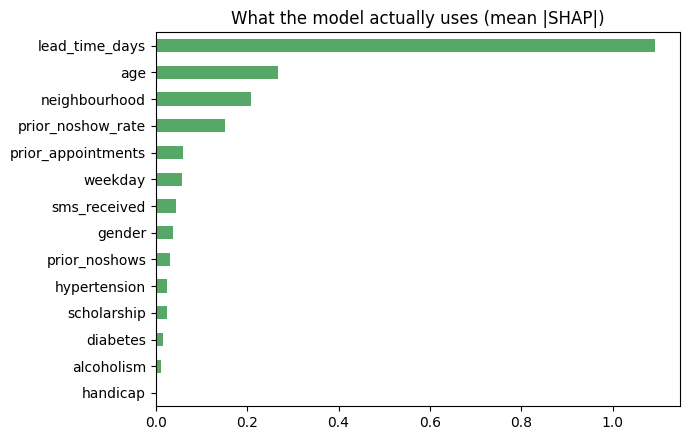

In [6]:
global_importance(art["model"], art["X_test"]).plot.barh(
    figsize=(7, 4.5), color="#55A868", title="What the model actually uses (mean |SHAP|)")
plt.tight_layout()
plt.show()

## 4. One patient, fully explained (local view)

The top row of today's call list, decomposed feature by feature. This is the
transparency a clinic needs before trusting the tool — and what regulators
increasingly expect from decision-support systems.

In [7]:
top_idx = day_df.index[0]
x_row = art["X_test"].loc[[top_idx]]
contribs, bias = shap_contributions(art["model"], x_row)

breakdown = (pd.DataFrame({
    "feature": x_row.columns,
    "value": [describe(f, x_row.iloc[0][f]) for f in x_row.columns],
    "contribution_logodds": contribs[0].round(3),
}).sort_values("contribution_logodds", key=abs, ascending=False))
print(f"Patient at top of the {day} call list — "
      f"calibrated p(no-show) = {day_df.loc[top_idx, 'p_noshow']:.1%}")
breakdown

Patient at top of the 2016-06-08 call list — calibrated p(no-show) = 99.0%


,feature,value,contribution_logodds
12,prior_noshows,15 prior no-shows,1.505
9,age,age 9,1.421
13,prior_noshow_rate,missed 100% of past visits,1.296
10,lead_time_days,booked 0d ahead,-0.681
11,prior_appointments,15 past visits,-0.470
1,neighbourhood,area SÃO JOSÉ,0.440
2,weekday,Wednesday,0.273
3,scholarship,welfare scholarship,0.207
0,gender,gender=M,0.167
5,diabetes,no diabetes,-0.022


## 5. Conclusions

**Two patients from today's call list**

- **Patient 90538 (p = 99%):** flagged because of 15 prior no-shows and a 100% historical miss rate, even though booking same-day usually lowers risk — history outweighs lead time here. Age 9 means the call goes to their parent or guardian.
- **Patient 102802 (p = 80%):** flagged mainly because they booked 176 days ahead and have missed 100% of past visits. Given that history, a better intervention than a reminder might be rescheduling to a sooner date or arranging transportation assistance, since the long lead time is a primary driver of their risk.

The feature **"Booked 32 days ahead (↑ risk)"** represents a correlation that the model learned from historical data. However, correlation does not prove causation. We cannot conclude that simply reducing the booking lead time will reduce no-show rates because other hidden factors may influence both appointment timing and patient attendance. To establish causation, a randomized controlled experiment (A/B test) would be required, where similar patients are randomly assigned to different booking lead times and their no-show rates are compared.

The dashboard reports **expected value** using only the model's predicted probabilities rather than the actual appointment outcomes. This is the correct approach for deployment because, in real-world use, future labels are unknown at the time decisions are made. Using predicted probabilities provides an honest estimate of the expected benefit of calling patients before the appointment occurs.

This approach has several limitations. The generated reasons explain the model's predictions, not the patient's actual thoughts or intentions. The intervention tier boundaries are still product design choices and may need refinement based on operational feedback. Finally, the evaluation uses a held-out test window as a substitute for future appointments. A live production system with continuous data collection and monitoring would be required to fully validate performance in real-world clinical settings.
